# Статистические методы (statsforecast)

Ряды короткие (~4031 точка, 14 суток). Основной период - 288 (сутки), 2016 учитываю только в MSTL. ARIMA с `season_length=288` считается >30 мин, так что AutoARIMA запускаю с `seasonal=False` на одном ряду. TBATS по той же причине пропущен.

In [1]:
# !pip install -q statsforecast utilsforecast


In [2]:
import sys, os
from pathlib import Path
ROOT = Path('.').resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)


In [3]:
from src.data import (
    load_panel, train_test_split_panel,
    DAILY_SEASON, WEEKLY_SEASON, FREQ,
)
from src.eval import make_metrics, make_probabilistic_metrics, evaluate_panel

panel = load_panel()
H_STAT = DAILY_SEASON          # горизонт = 1 сутки = 288 шагов

# Hold-out: последние H_STAT точек каждого ряда
_test_raw = panel.groupby('unique_id').tail(H_STAT)
train_fold = panel.drop(_test_raw.index).reset_index(drop=True)
test_fold = _test_raw.reset_index(drop=True)

print(f'Train: {len(train_fold)} rows, Test: {len(test_fold)} rows, H={H_STAT}')
print(f'Per series: train={len(train_fold)//3}, test={len(test_fold)//3}')


Train: 11229 rows, Test: 864 rows, H=288
Per series: train=3743, test=288


## Бейзлайны

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive, RandomWalkWithDrift,
    AutoETS, AutoTheta, HoltWinters,
    MSTL, AutoARIMA,
)

baseline_models = [
    Naive(alias='Naive'),
    SeasonalNaive(season_length=DAILY_SEASON, alias='SNaive'),
    RandomWalkWithDrift(alias='RWD'),
]
sf_base = StatsForecast(models=baseline_models, freq=FREQ, n_jobs=-1)
fcst_base = sf_base.forecast(df=train_fold, h=H_STAT)
eval_base = test_fold.merge(fcst_base, on=['unique_id', 'ds'])

metrics, metric_names = make_metrics(seasonality=DAILY_SEASON)
metrics_base = evaluate_panel(
    eval_df=eval_base, train_df=train_fold,
    model_names=['Naive', 'SNaive', 'RWD'], metrics=metrics,
)
print('Бейзлайны:')
metrics_base


Бейзлайны:


,unique_id,Naive,SNaive,RWD
metric,,,,
mae,ec2_cpu_utilization_24ae8d,0.022028,0.046806,0.022093
mae,ec2_cpu_utilization_53ea38,0.066986,0.056646,0.067828
mae,ec2_cpu_utilization_5f5533,0.798035,0.740431,0.980463
rmse,ec2_cpu_utilization_24ae8d,0.096486,0.184996,0.096491
rmse,ec2_cpu_utilization_53ea38,0.099550,0.087601,0.099294
rmse,ec2_cpu_utilization_5f5533,1.111668,0.940235,1.286547
smape,ec2_cpu_utilization_24ae8d,0.076150,0.133622,0.076387
smape,ec2_cpu_utilization_53ea38,0.018116,0.015304,0.018348
smape,ec2_cpu_utilization_5f5533,0.010395,0.009677,0.012826


Baseline для всех сравнений - `SeasonalNaive(288)`.

## ETS-семейство (AutoETS, AutoTheta, HoltWinters)

In [5]:
ets_models = [
    AutoETS(season_length=DAILY_SEASON, model='ZZA', damped=False, alias='ETS'),
    AutoTheta(season_length=DAILY_SEASON, decomposition_type='additive', alias='Theta'),
    HoltWinters(season_length=DAILY_SEASON, error_type='A', alias='HW'),
]
sf_ets = StatsForecast(models=ets_models, freq=FREQ, n_jobs=-1)
fcst_ets = sf_ets.forecast(df=train_fold, h=H_STAT)
eval_ets = test_fold.merge(fcst_ets, on=['unique_id', 'ds'])

metrics_ets = evaluate_panel(
    eval_df=eval_ets, train_df=train_fold,
    model_names=['ETS', 'Theta', 'HW'], metrics=metrics,
)
print('ETS-семейство:')
metrics_ets


ETS-семейство:


,unique_id,ETS,Theta,HW
metric,,,,
mae,ec2_cpu_utilization_24ae8d,0.058199,0.031999,0.031858
mae,ec2_cpu_utilization_53ea38,0.047196,0.053910,0.048175
mae,ec2_cpu_utilization_5f5533,6.104160,0.894017,0.783078
rmse,ec2_cpu_utilization_24ae8d,0.109294,0.097426,0.097593
rmse,ec2_cpu_utilization_53ea38,0.070623,0.076648,0.071582
rmse,ec2_cpu_utilization_5f5533,7.115751,1.139108,0.998832
smape,ec2_cpu_utilization_24ae8d,0.254039,0.107657,0.107200
smape,ec2_cpu_utilization_53ea38,0.012834,0.014638,0.013095
smape,ec2_cpu_utilization_5f5533,0.072094,0.011759,0.010229


## MSTL (мульти-сезонная декомпозиция)

Используем `[DAILY_SEASON, WEEKLY_SEASON]` - две сезонности одновременно.

In [6]:
decomp_models = [
    MSTL(season_length=[DAILY_SEASON], alias='MSTL_d'),       # только суточная
    MSTL(season_length=[DAILY_SEASON, WEEKLY_SEASON], alias='MSTL_dw'),  # сут + нед
]
sf_dec = StatsForecast(models=decomp_models, freq=FREQ, n_jobs=-1)
fcst_dec = sf_dec.forecast(df=train_fold, h=H_STAT)
eval_dec = test_fold.merge(fcst_dec, on=['unique_id', 'ds'])

metrics_dec = evaluate_panel(
    eval_df=eval_dec, train_df=train_fold,
    model_names=['MSTL_d', 'MSTL_dw'], metrics=metrics,
)
print('MSTL варианты:')
metrics_dec


MSTL варианты:


,unique_id,MSTL_d,MSTL_dw
metric,,,
mae,ec2_cpu_utilization_24ae8d,0.035408,0.047286
mae,ec2_cpu_utilization_53ea38,0.057027,0.073461
mae,ec2_cpu_utilization_5f5533,0.928939,2.452214
rmse,ec2_cpu_utilization_24ae8d,0.105599,0.146787
rmse,ec2_cpu_utilization_53ea38,0.080236,0.104918
rmse,ec2_cpu_utilization_5f5533,1.165103,3.030209
smape,ec2_cpu_utilization_24ae8d,0.118511,0.153215
smape,ec2_cpu_utilization_53ea38,0.015457,0.019703
smape,ec2_cpu_utilization_5f5533,0.012207,0.032355


## AutoARIMA (1 ряд, без сезонности)

In [7]:
uid_focus = panel['unique_id'].iloc[0]
train_one = train_fold[train_fold['unique_id'] == uid_focus]
test_one = test_fold[test_fold['unique_id'] == uid_focus]
print(f'Фокус-ряд: {uid_focus}')

auto_arima = [AutoARIMA(
    seasonal=False, max_p=3, max_q=3, max_d=2,
    ic='aicc', stepwise=True, alias='AutoARIMA',
)]
sf_arima = StatsForecast(models=auto_arima, freq=FREQ, n_jobs=-1)
fcst_arima = sf_arima.forecast(df=train_one, h=H_STAT)
eval_arima = test_one.merge(fcst_arima, on=['unique_id', 'ds'])

m_arima = evaluate_panel(
    eval_df=eval_arima, train_df=train_one,
    model_names=['AutoARIMA'], metrics=metrics,
)
print('AutoARIMA (1 ряд):')
m_arima


Фокус-ряд: ec2_cpu_utilization_24ae8d


AutoARIMA (1 ряд):


,unique_id,AutoARIMA
metric,,
mae,ec2_cpu_utilization_24ae8d,0.026073
rmse,ec2_cpu_utilization_24ae8d,0.096462
smape,ec2_cpu_utilization_24ae8d,0.092219
mase,ec2_cpu_utilization_24ae8d,0.720022


## Prophet

In [8]:
try:
    from prophet import Prophet
    prophet_results = {}
    for uid, g in train_fold.groupby('unique_id'):
        df_p = g[['ds','y']].copy()
        m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False,
                   changepoint_prior_scale=0.05, interval_width=0.9)
        m.fit(df_p)
        future = m.make_future_dataframe(periods=H_STAT, freq=FREQ, include_history=False)
        fcst = m.predict(future)
        prophet_results[uid] = pd.DataFrame({
            'unique_id': uid, 'ds': fcst['ds'].values,
            'Prophet': fcst['yhat'].values,
        })
    fcst_prophet = pd.concat(prophet_results.values(), ignore_index=True)
    eval_prophet = test_fold.merge(fcst_prophet, on=['unique_id', 'ds'])
    m_prophet = evaluate_panel(eval_df=eval_prophet, train_df=train_fold,
                              model_names=['Prophet'], metrics=metrics)
    print('Prophet:')
    display(m_prophet)
except ImportError:
    print('Prophet не установлен; пропускаем.')
    eval_prophet = None; m_prophet = None
except Exception as e:
    print(f'Prophet failed: {e}')
    eval_prophet = None; m_prophet = None


Prophet не установлен; пропускаем.


## Probabilistic-forecast (точечный + интервалы)

In [9]:
prob_models = [
    SeasonalNaive(season_length=DAILY_SEASON, alias='SNaive'),
    AutoETS(season_length=DAILY_SEASON, model='ZZA', damped=False, alias='ETS'),
    MSTL(season_length=[DAILY_SEASON], alias='MSTL'),
]
LEVELS = [80, 90]
sf_prob = StatsForecast(models=prob_models, freq=FREQ, n_jobs=-1)
fcst_prob = sf_prob.forecast(df=train_fold, h=H_STAT, level=LEVELS)
eval_prob = test_fold.merge(fcst_prob, on=['unique_id', 'ds'])

prob_metrics, prob_names = make_probabilistic_metrics(seasonality=DAILY_SEASON)
metrics_prob = evaluate_panel(
    eval_df=eval_prob, train_df=train_fold,
    model_names=['SNaive', 'ETS', 'MSTL'],
    metrics=prob_metrics, level=LEVELS,
)
print('Probabilistic forecasts:')
metrics_prob


Probabilistic forecasts:


,unique_id,SNaive,ETS,MSTL
metric,,,,
mae,ec2_cpu_utilization_24ae8d,0.046806,0.058199,0.035408
mae,ec2_cpu_utilization_53ea38,0.056646,0.047196,0.057027
mae,ec2_cpu_utilization_5f5533,0.740431,6.104160,0.928939
rmse,ec2_cpu_utilization_24ae8d,0.184996,0.109294,0.105599
rmse,ec2_cpu_utilization_53ea38,0.087601,0.070623,0.080236
rmse,ec2_cpu_utilization_5f5533,0.940235,7.115751,1.165103
smape,ec2_cpu_utilization_24ae8d,0.133622,0.254039,0.118511
smape,ec2_cpu_utilization_53ea38,0.015304,0.012834,0.015457
smape,ec2_cpu_utilization_5f5533,0.009677,0.072094,0.012207


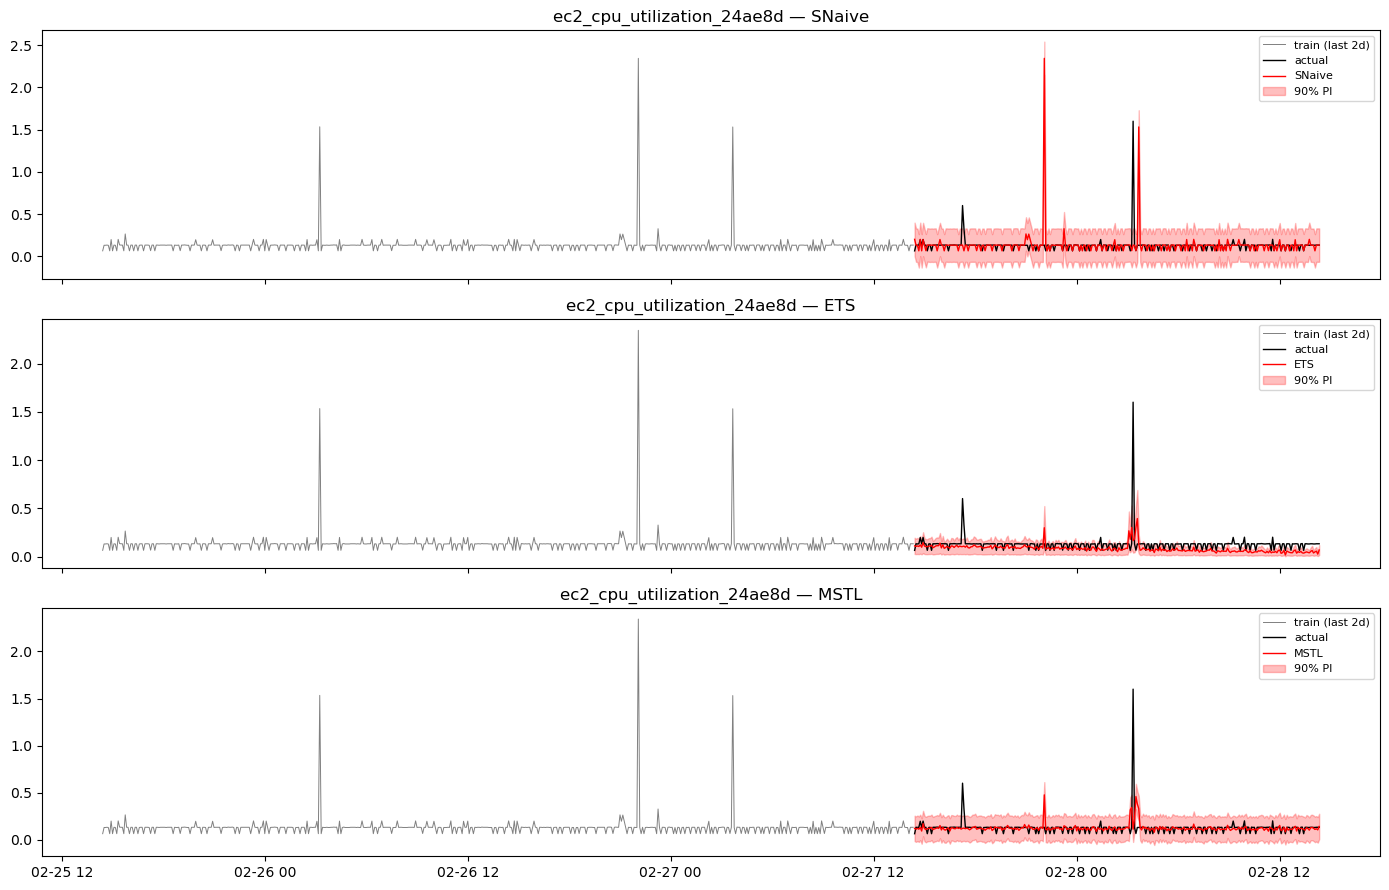

In [10]:
# Визуализация интервалов для одного ряда
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
uid_viz = panel['unique_id'].iloc[0]
sub_train = train_fold[train_fold['unique_id']==uid_viz].tail(2*DAILY_SEASON)
sub_eval  = eval_prob[eval_prob['unique_id']==uid_viz]

for ax, model in zip(axes, ['SNaive', 'ETS', 'MSTL']):
    ax.plot(sub_train['ds'], sub_train['y'], color='gray', label='train (last 2d)', linewidth=0.7)
    ax.plot(sub_eval['ds'], sub_eval['y'], color='black', label='actual', linewidth=1)
    ax.plot(sub_eval['ds'], sub_eval[model], color='red', label=model, linewidth=1)
    lo, hi = f'{model}-lo-90', f'{model}-hi-90'
    if lo in sub_eval.columns:
        ax.fill_between(sub_eval['ds'], sub_eval[lo], sub_eval[hi], alpha=0.25, color='red', label='90% PI')
    ax.set_title(f'{uid_viz} - {model}')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('report/figures/02_prob_forecasts.png', dpi=120, bbox_inches='tight')
plt.show()


## Backtest через cross_validation

In [11]:
# топовые модели на rolling-origin CV
cv_models = [
    SeasonalNaive(season_length=DAILY_SEASON, alias='SNaive'),
    AutoETS(season_length=DAILY_SEASON, model='ZZA', alias='ETS'),
    AutoTheta(season_length=DAILY_SEASON, alias='Theta'),
    MSTL(season_length=[DAILY_SEASON], alias='MSTL'),
]
sf_cv = StatsForecast(models=cv_models, freq=FREQ, n_jobs=-1)

cv_conf = dict(
    h=H_STAT, n_windows=3, step_size=H_STAT, refit=True,
)
cv_df = sf_cv.cross_validation(df=panel, **cv_conf)
print(f'CV окон: {cv_df["cutoff"].nunique()}')
cv_df.head(3)


CV окон: 3


,unique_id,ds,cutoff,y,SNaive,ETS,Theta,MSTL
0,ec2_cpu_utilization_24ae8d,2014-02-25 14:25:00,2014-02-25 14:20:00,0.066,0.066,0.119108,0.118649,0.118282
1,ec2_cpu_utilization_24ae8d,2014-02-25 14:30:00,2014-02-25 14:20:00,0.132,0.134,0.105575,0.111655,0.106510
2,ec2_cpu_utilization_24ae8d,2014-02-25 14:35:00,2014-02-25 14:20:00,0.132,0.132,0.119182,0.116911,0.126108


In [12]:
from utilsforecast.evaluation import evaluate
cv_metrics = evaluate(
    cv_df, metrics=metrics,
    models=[m.alias for m in cv_models],
    train_df=panel, cutoff_col='cutoff',
)
# Усреднение по cutoff
avg = cv_metrics.groupby(['unique_id', 'metric']).mean(numeric_only=True)
print('Средние метрики по CV (по unique_id × metric):')
avg


Средние метрики по CV (по unique_id × metric):


SNaive       ETS     Theta      MSTL
unique_id                  metric                                        
ec2_cpu_utilization_24ae8d mae     0.043134  0.048784  0.037235  0.038512
                           mase    1.209518  1.367106  1.045762  1.081160
                           rmse    0.164445  0.121783  0.116689  0.122476
                           smape   0.131487  0.185189  0.122660  0.125455
ec2_cpu_utilization_53ea38 mae     0.056600  0.046521  0.049139  0.050267
                           mase    0.911520  0.749391  0.791800  0.810093
                           rmse    0.079469  0.067751  0.070636  0.071432
                           smape   0.015334  0.012605  0.013320  0.013601
ec2_cpu_utilization_5f5533 mae     1.133063  0.851086  0.801216  0.963724
                           mase    0.297572  0.227134  0.214689  0.257627
                           rmse    1.758945  1.075356  1.032110  1.207954
                           smape   0.014329  0.011124  0.010486  0.012639

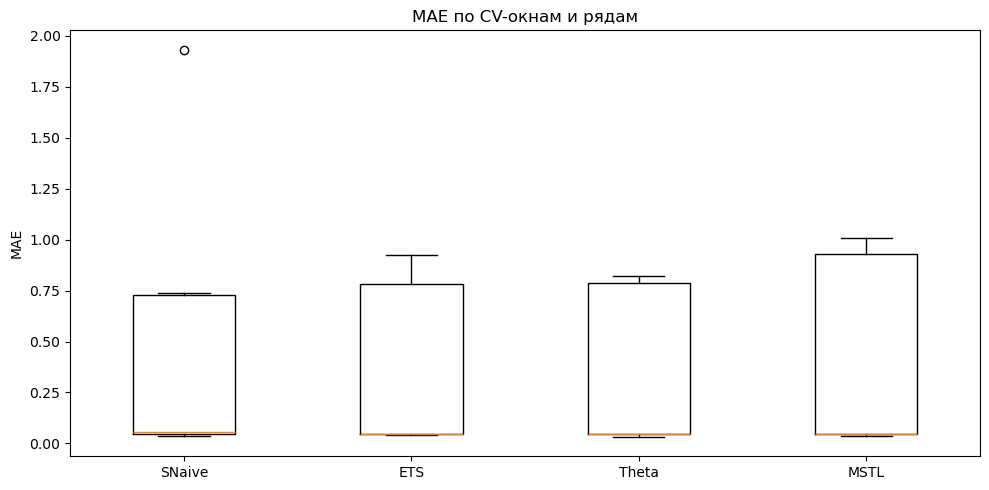

In [13]:
# Boxplot ошибок MAE по CV-окнам и рядам
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mae_df = cv_metrics[cv_metrics['metric'] == 'mae']
model_cols = [m_.alias for m_ in cv_models]
data = [mae_df[col].dropna().values for col in model_cols]
ax.boxplot(data, labels=model_cols)
ax.set_title('MAE по CV-окнам и рядам'); ax.set_ylabel('MAE')
plt.tight_layout()
plt.savefig('report/figures/02_cv_mae.png', dpi=120, bbox_inches='tight')
plt.show()


## Сводная таблица + победитель

In [14]:
# общий hold-out по всем моделям (ARIMA отдельно, она на 1 ряду)
all_models = baseline_models + ets_models + decomp_models
sf_all = StatsForecast(models=all_models, freq=FREQ, n_jobs=-1)
fcst_all = sf_all.forecast(df=train_fold, h=H_STAT)
eval_all = test_fold.merge(fcst_all, on=['unique_id', 'ds'])

aliases = [m.alias for m in all_models]
metrics_all = evaluate_panel(
    eval_df=eval_all, train_df=train_fold,
    model_names=aliases, metrics=metrics,
)
# Среднее по рядам и по метрикам
mean_per_model = metrics_all.groupby('metric').mean(numeric_only=True).T
# Композитный ранг = сумма рангов по точечным метрикам (меньше - лучше)
mean_per_model['composite_rank'] = mean_per_model[metric_names].rank().sum(axis=1)
mean_per_model = mean_per_model.sort_values('composite_rank')
print('Сводная таблица (среднее по рядам, отсортировано по composite rank):')
mean_per_model


Сводная таблица (среднее по рядам, отсортировано по composite rank):


metric,mae,mase,rmse,smape,composite_rank
HW,0.287704,0.628551,0.389336,0.043508,7.0
Naive,0.295683,0.641393,0.435902,0.034887,9.0
SNaive,0.281294,0.807993,0.404277,0.052868,15.0
Theta,0.326642,0.671444,0.437728,0.044684,16.0
RWD,0.356794,0.663857,0.494111,0.035854,17.0
MSTL_d,0.340458,0.723020,0.450313,0.048725,20.0
MSTL_dw,0.857654,1.065913,1.093971,0.068424,28.0
ETS,2.069852,1.370540,2.431889,0.112989,32.0


In [15]:
import json
out = Path('data/processed'); out.mkdir(parents=True, exist_ok=True)
eval_all.to_parquet(out / 'stats_forecasts.parquet', index=False)
eval_prob.to_parquet(out / 'stats_prob_forecasts.parquet', index=False)
metrics_all.to_csv(out / 'stats_metrics.csv')

winner_stat = mean_per_model.index[0]
with open(out / 'winner_stat.json', 'w') as f:
    json.dump({'winner_stat': winner_stat, 'h_stat': H_STAT}, f)
print(f'Победитель stats: {winner_stat}')


Победитель stats: HW
